In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
    return 4*x**2-4*x+5


In [ ]:
f(4)

53

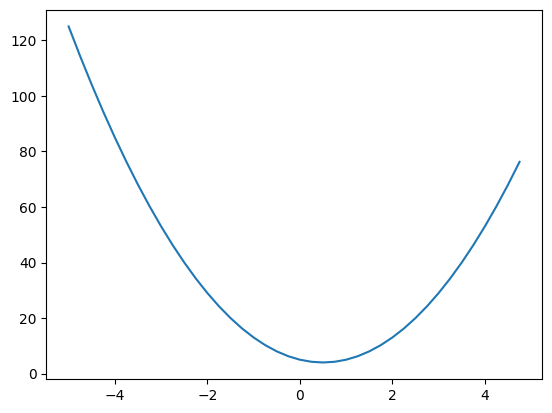

In [ ]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs, ys)

In [ ]:
h=0.001
x=4
(f(x+h) - f(x)) / h

28.00400000000991

In [ ]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d=a*b+c
print(d)


4.0


In [ ]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1, d2, (d2-d1)/h)

4.0 3.999699999999999 -3.000000000010772


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    def __rmul__(self, other):  # other * self
        return self * other
    def __truediv__(self, other):  # self / other
        return self * other**-1
    def __neg__(self):  # -self
        return self * -1
    def __sub__(self, other):  # self - other
        return self + (-other)
    def __rsub__(self, other):  # other - self
        return other + (-self)
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad+=out.grad*other.data
            other.grad+=out.grad*self.data
        out._backward=_backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out=Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad+=out.grad*other*self.data**(other-1)
        out._backward=_backward
        return out
    def tanh(self):
        x=self.data
        t=(math.exp(x*2)-1)/(math.exp(x*2)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=out.grad*(1-t**2)
        out._backward=_backward
        return out
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f= Value(-2.0, label='f')
L=d * f; L.label = 'L'
L


Value(data=-8.0)

In [ ]:
a=Value(2.0, label='a')
b=Value(4.0, label='b')
a-b

Value(data=-2.0)

In [ ]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [ ]:
d._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
    #built a set of all the nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR= left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph, create a rectangular ('record') node for  it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            #and connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        #for each edge, connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [ ]:
def lol():
    h=0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L1=L.data
    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L2=L.data
    print((L2-L1)/h)

lol()


6.000000000021544


In [ ]:
#input x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'
o.backward()

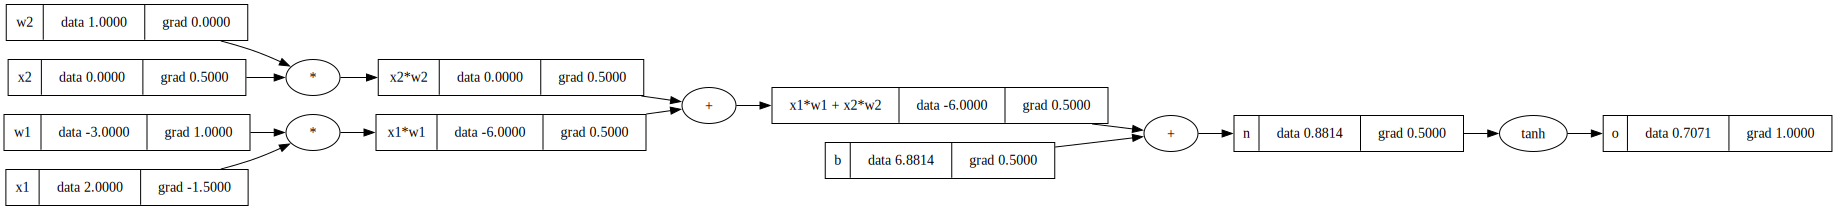

In [ ]:
draw_dot(o)

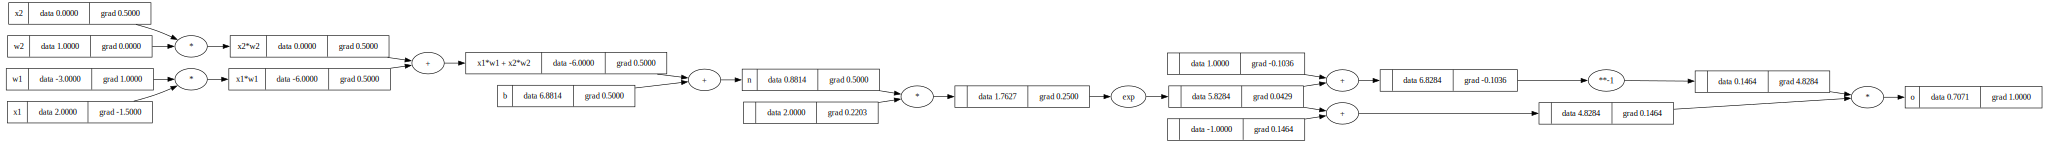

In [ ]:
#input x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b; n.label='n'
#---
e=(2*n).exp()
o=(e-1)/(e+1)
o.label='o'
o.backward()
draw_dot(o)

In [ ]:
import torch
import random

In [ ]:


x1=torch.Tensor([2.0]).double()              ;x1.requires_grad_(True)
x2=torch.Tensor([0.0]).double()              ;x2.requires_grad_(True)
w1=torch.Tensor([-3.0]).double()             ;w1.requires_grad_(True)
w2=torch.Tensor([1.0]).double()              ;w2.requires_grad_(True)
b=torch.Tensor([6.8813735870195432]).double() ;b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
o.item()

0.7071066904050358

In [ ]:
class Neuron:
    def __init__(self,nin):
        self.w=[(Value(random.uniform(-1,1))) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    
    def __call__(self,x):
        # w*x+b
        act=sum((wi*xi for wi,xi in  zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    
    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        


In [ ]:
x=[2.0, 3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=-0.18792733771153802)

In [ ]:
n.parameters()

[Value(data=0.3037959817418814),
 Value(data=-0.790461445129806),
 Value(data=0.8243618282787346),
 Value(data=0.9323193539497157),
 Value(data=-0.13036375303898473),
 Value(data=-0.46807871176811644),
 Value(data=0.45332838175393686),
 Value(data=-0.2350919233210873),
 Value(data=-0.3499664551272268),
 Value(data=0.7253204848865211),
 Value(data=0.07131475577334578),
 Value(data=0.7886649377980353),
 Value(data=0.6252561014140037),
 Value(data=-0.8656505084974551),
 Value(data=0.4433158251128251),
 Value(data=0.2274444039238701),
 Value(data=0.5165606956716338),
 Value(data=-0.9078057895680065),
 Value(data=0.6461729827885909),
 Value(data=0.2109286605101881),
 Value(data=-0.8212342304119287),
 Value(data=-0.39408699498212907),
 Value(data=0.14658415803910674),
 Value(data=0.8706540043252928),
 Value(data=-0.30328950224501994),
 Value(data=0.6062344300044775),
 Value(data=-0.3417200753792753),
 Value(data=-0.037526813769150236),
 Value(data=0.6678717490282327),
 Value(data=-0.02260561

In [ ]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys=[1.0,-1.0,-1.0,1.0]
ypred=[n(x) for x in xs]
ypred

[Value(data=-0.18792733771153802),
 Value(data=0.874793018029763),
 Value(data=-0.4815066210897927),
 Value(data=-0.33375279454374285)]

In [ ]:
for k in range(10):
    ypred=[n(x) for x in xs]
    loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
    print(k, loss.data)
    
    for p in n.parameters():
        p.grad=0.0
    
    loss.backward()
    
    for p in n.parameters():
        p.data+=-0.01*p.grad
    print(k, loss.data)

0 6.973752121062537
0 6.973752121062537
1 6.1297990717428625
1 6.1297990717428625
2 5.450867157310512
2 5.450867157310512
3 4.928555131244722
3 4.928555131244722
4 4.480132949599927
4 4.480132949599927
5 4.018083841146324
5 4.018083841146324
6 3.4631451459507936
6 3.4631451459507936
7 2.7647602308062194
7 2.7647602308062194
8 2.001622304445459
8 2.001622304445459
9 1.4112743183668084
9 1.4112743183668084


In [ ]:
loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
loss


Value(data=1.4112743183668084)

In [ ]:
loss.backward()

In [ ]:
n.layers[0].neurons[0].w[0].grad

7.8659842636547825

In [ ]:
n.layers[0].neurons[0].w[0].data

0.23287553588432316

In [ ]:
for p in n.parameters():
    p.data+=-0.01*p.grad

In [ ]:
n.layers[0].neurons[0].w[0].data

0.15421569324777534